# 06 · Matriz territorial y controles — final técnico de fase D

Integra exclusivamente por `cell_id`, validando uniones 1:1 y cobertura de todas las celdas. El maestro contiene variables candidatas; geometría reconstruible y calidad están separadas. Los indicios se conservan en una relación auxiliar y se agregan a una fila por celda, sin convertir U en negativos.

No crea particiones, imputaciones ni Random Forest: corresponden a E/F. La lista de variables aprobadas para entrenamiento permanece vacía hasta revisión científica. No usar todas las columnas de calidad/etiquetas como X.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/geoau/features.py').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd
import matplotlib.pyplot as plt
from geoau import features as fd

RUN = fd.current_run(ROOT)
print(RUN)

C:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\reports\fase_d\20260908T131414_539995Z


In [2]:
X, quality, labels = fd.assemble(ROOT, RUN)
display(fd.read_json(RUN / 'control_cierre.json'))

Bloque verificado: geology


Bloque verificado: structural


Bloque verificado: geochemistry


Bloque verificado: terrain


Bloque verificado: hydrology


Fase D terminada técnicamente: 496855 celdas; 162 variables candidatas.


{'estado_ejecucion': 'completada',
 'fase_d_cientifica_cerrada': False,
 'prediction_allowed': False,
 'cells': 496855,
 'candidate_features': 162,
 'assigned_candidates': 789,
 'occupied_candidate_cells': 691,
 'reviewed_positive_cells': 0,
 'scope': 'peninsula_componente_principal',
 'grid_version': 'es_pen_utm30_1km_v1'}

In [3]:
display(pd.read_csv(RUN / 'variables_qc.csv').sort_values('missing_fraction', ascending=False).head(25))
display(labels.estado_etiqueta.value_counts())
display(fd.read_json(RUN / 'pending_extensions.json'))

,variable,missing_fraction,n_unique
69,dist_contacto_intrusivo_supuesta_m,0.979990,9940
131,pb_proporcion_clase_4,0.816937,1
134,pb_proporcion_clase_7,0.816937,1
128,pb_proporcion_clase_1,0.816937,1
127,pb_proporcion_clase_0,0.816937,1
126,pb_clase_modal,0.816937,2
133,pb_proporcion_clase_6,0.816937,4
132,pb_proporcion_clase_5,0.816937,1
129,pb_proporcion_clase_2,0.816937,4
130,pb_proporcion_clase_3,0.816937,1


estado_etiqueta
U                        496164
candidato_no_revisado       691
Name: count, dtype: int64

{'geological_groups': 'revisión de unidades mixtas y equivalencias; fracciones actuales son unidades originales',
 'geophysics': 'gravimetría: unidades/campañas/soporte; vuelos/MT/petro no se interpolan como propiedades',
 'advanced_structures': 'leyendas angulares, intersecciones y topología pendientes',
 'alluvial': 'cuaternario genérico no distingue terrazas; MDT fino y cuencas pendientes',
 'geochemistry': 'contraste RGB local ejecutado; leyendas oficiales, medio y extracción pendientes',
 'density': 'aproximación por distribución uniforme de longitud dentro de celdas de 1km; validar sensibilidad',
 'territory': 'máscara regional candidata y cobertura de levantamientos pendientes'}

## Revisión espacial
El mapa siguiente muestra una variable, no prospectividad. Revisar costa, huecos y discontinuidades entre hojas. Los bloques diagnósticos heredados de C no son particiones de validación.

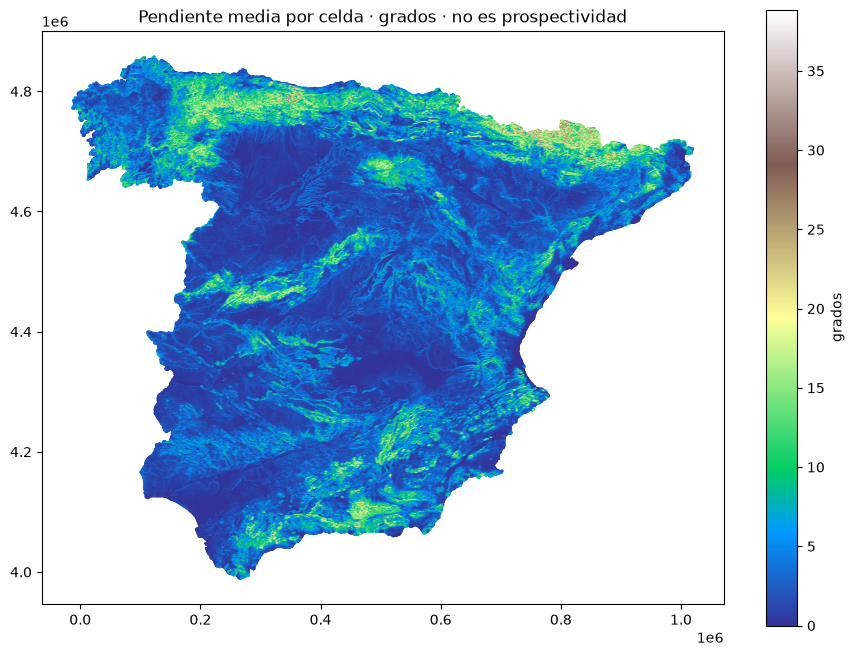

In [4]:
plot = quality[['cell_id', 'x_center', 'y_center']].merge(X[['cell_id', 'pendiente_grados']], on='cell_id', validate='one_to_one')
fig, ax = plt.subplots(figsize=(11, 8))
m = ax.scatter(plot.x_center, plot.y_center, c=plot.pendiente_grados, s=1, cmap='terrain', rasterized=True)
ax.set_aspect('equal')
ax.set_title('Pendiente media por celda · grados · no es prospectividad')
fig.colorbar(m, ax=ax, label='grados')
plt.show()

In [5]:
fd.verify_records(RUN, fd.read_json(RUN / 'outputs_manifest.json'))
print('Productos sellados verificados:', RUN)

Productos sellados verificados: C:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\reports\fase_d\20260908T131414_539995Z
